In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense



In [4]:
df = pd.read_csv("../outputs/delhi_merged_daily.csv")
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["month"] = df["date"].dt.month

df.head()

,date,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),temperature_2m (°C),relative_humidity_2m (%),wind_speed_10m (km/h),month
0,2024-01-01,176.679583,293.727083,33.182917,10.389583,1.177917,15.869583,10.145833,85.166667,5.633333,1
1,2024-01-02,64.670000,97.460417,38.033750,11.236250,1.051667,18.985000,8.966667,85.750000,5.420833,1
2,2024-01-03,91.241667,216.910833,58.340417,15.130833,1.385417,37.907500,9.550000,88.166667,5.462500,1
3,2024-01-04,53.814167,135.506667,32.885833,17.690417,0.845000,32.325000,11.937500,82.041667,6.379167,1
4,2024-01-05,65.398333,225.740833,31.865000,16.080417,0.905833,51.816667,11.266667,86.041667,5.125000,1


In [5]:
features = [
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "wind_speed_10m (km/h)",
    "month"
]

X = df[features]
y = df["PM2.5 (µg/m³)"]


In [6]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [7]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R2:", r2_score(y_test, y_pred_gbr))


Gradient Boosting
MAE: 26.7961781614159
RMSE: 45.61052100369462
R2: 0.8104709198487546


In [78]:
# Weighted Ensemble for Delhi (RF + GBR)

rf_pred = rf.predict(X_test)
gbr_pred = gbr.predict(X_test)

# equal weights (safe starting point)
w_rf = 0.5
w_gbr = 0.5

ensemble_pred = (w_rf * rf_pred) + (w_gbr * gbr_pred)

print("\nDelhi – Weighted Ensemble (RF + GBR)")
print("MAE:", mean_absolute_error(y_test, ensemble_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ensemble_pred)))
print("R2:", r2_score(y_test, ensemble_pred))



Delhi – Weighted Ensemble (RF + GBR)
MAE: 4.5279523035133105
RMSE: 5.502805620591825
R2: 0.6368367267837847


In [8]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))


In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
evaluate_model("Linear Regression", y_test, y_pred_lr)



Linear Regression
MAE : 29.932823647364938
RMSE: 41.86914662463516
R²  : 0.8402893022972584


In [10]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

evaluate_model("Random Forest", y_test, y_pred_rf)



Random Forest
MAE : 26.149940523633752
RMSE: 44.977900639207995
R²  : 0.8156920154972133


In [11]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)
evaluate_model("Gradient Boosting", y_test, y_pred_gbr)



Gradient Boosting
MAE : 26.7961781614159
RMSE: 45.61052100369462
R²  : 0.8104709198487546


In [12]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importances


PM10 (µg/m³)                0.842406
CO (mg/m³)                  0.066129
NO2 (µg/m³)                 0.028653
SO2 (µg/m³)                 0.026693
Ozone (µg/m³)               0.013688
wind_speed_10m (km/h)       0.007515
temperature_2m (°C)         0.006602
relative_humidity_2m (%)    0.006550
month                       0.001765
dtype: float64

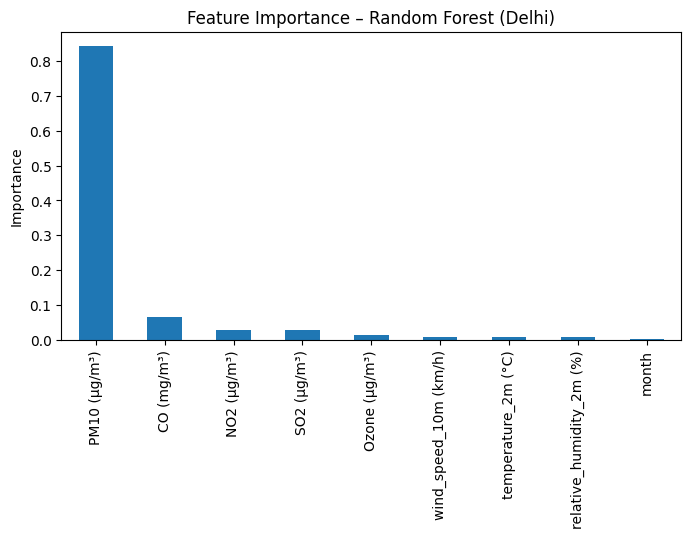

In [13]:
importances.plot(kind="bar", figsize=(8,4))
plt.title("Feature Importance – Random Forest (Delhi)")
plt.ylabel("Importance")
plt.show()


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [15]:
def create_sequences(X, y, window=7):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=7)

split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]


In [16]:
import tensorflow as tf
tf.__version__


'2.20.0'

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


d:\CU\Research Paper\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 11052.3574 - val_loss: 9635.0625
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10928.3984 - val_loss: 9431.1875
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 10687.7227 - val_loss: 9035.6416
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10247.3467 - val_loss: 8570.0967
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9799.2490 - val_loss: 8221.5371
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9508.1055 - val_loss: 7995.7480
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9321.7314 - val_loss: 7839.2456
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9183.7861 - val_loss: 7710.3208
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9065.2646 - val_loss: 7597.3076
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8957.5176 - val_loss: 7489.1504
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8855.2705 - val_loss: 7385.8003
Epoch 12/20
9/9

In [19]:
y_pred_lstm = model.predict(X_test_seq).flatten()

evaluate_model("LSTM", y_test_seq, y_pred_lstm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

LSTM
MAE : 159.9196315191085
RMSE: 191.74394788038276
R²  : -2.2744894751399434


In [20]:
df = pd.read_csv("../outputs/mumbai_merged_daily.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df["month"] = df["date"].dt.month


In [21]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))


In [22]:
features = [
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "wind_speed_10m (km/h)",
    "month"
]

required_cols = ["PM2.5 (µg/m³)"] + features

df = df[required_cols].dropna()


In [23]:
df.isnull().sum()


PM2.5 (µg/m³)               0
PM10 (µg/m³)                0
NO2 (µg/m³)                 0
SO2 (µg/m³)                 0
CO (mg/m³)                  0
Ozone (µg/m³)               0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
wind_speed_10m (km/h)       0
month                       0
dtype: int64

In [24]:
X = df[features]
y = df["PM2.5 (µg/m³)"]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate("Mumbai - Linear Regression", y_test, lr.predict(X_test))



Mumbai - Linear Regression
MAE : 7.751903448494364
RMSE: 10.02458851807858
R²  : 0.5963716832238688


In [26]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
evaluate("Mumbai – Random Forest", y_test, rf.predict(X_test))



Mumbai – Random Forest
MAE : 15.50409200506083
RMSE: 18.66434360722234
R²  : -0.3991811930379112


In [27]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
evaluate("Mumbai – Gradient Boosting", y_test, gbr.predict(X_test))



Mumbai – Gradient Boosting
MAE : 12.857575100425432
RMSE: 15.552453743839598
R²  : 0.028492062260004558


In [28]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [29]:
def create_sequences(X, y, window=7):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=7)


In [30]:
split_seq = int(len(X_seq) * 0.8)

X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]


In [31]:
model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, verbose=1)


Epoch 1/15


d:\CU\Research Paper\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 955.4684
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 912.5518 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 835.1957  
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 703.2820 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 581.1860 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 501.2708 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 456.8073 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 427.3107 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 404.2965 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 386.3506 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 370.2881 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 356.3533 
Epoch 13/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 343.6328 
Epoch 14/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 332.2478 
Epoch 15/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 323.0062


In [32]:
y_pred_lstm = model.predict(X_test_seq).flatten()
evaluate("Mumbai – LSTM", y_test_seq, y_pred_lstm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Mumbai – LSTM
MAE : 42.62191109791029
RMSE: 44.79341875052725
R²  : -9.107336171906914


In [33]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))


In [34]:
df = pd.read_csv("../outputs/bengaluru_merged_daily.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

df["month"] = df["date"].dt.month


In [35]:
features = [
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "wind_speed_10m (km/h)",
    "month"
]

required_cols = ["PM2.5 (µg/m³)"] + features
df = df[required_cols].dropna()


In [36]:
df.isnull().sum()


PM2.5 (µg/m³)               0
PM10 (µg/m³)                0
NO2 (µg/m³)                 0
SO2 (µg/m³)                 0
CO (mg/m³)                  0
Ozone (µg/m³)               0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
wind_speed_10m (km/h)       0
month                       0
dtype: int64

In [37]:
X = df[features]
y = df["PM2.5 (µg/m³)"]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [38]:
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate("Bengaluru – Linear Regression", y_test, lr.predict(X_test))



Bengaluru – Linear Regression
MAE : 4.036430391712491
RMSE: 4.800148006693379
R²  : 0.8176978634693218


In [39]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
evaluate("Bengaluru – Random Forest", y_test, rf.predict(X_test))



Bengaluru – Random Forest
MAE : 4.218522557471287
RMSE: 5.097568776321898
R²  : 0.7944068269068868


In [40]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
evaluate("Bengaluru – Gradient Boosting", y_test, gbr.predict(X_test))



Bengaluru – Gradient Boosting
MAE : 4.64300449788021
RMSE: 5.780707436490675
R²  : 0.7356103306280994


In [41]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [42]:
def create_sequences(X, y, window=7):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=7)


In [43]:
split_seq = int(len(X_seq) * 0.8)

X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]


In [44]:
model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, verbose=1)


Epoch 1/15


d:\CU\Research Paper\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1293.4150
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1270.9236
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1247.5352
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1219.4917
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1182.5698
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1130.6910 
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1062.0072
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 980.5824 
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 900.6660
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 831.7858
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 775.6439
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 727.5330
Epoch 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 688.9752
Epoch 14/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 654.8887
Epoch 15/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 630.7247


In [45]:
y_pred_lstm = model.predict(X_test_seq).flatten()
evaluate("Bengaluru – LSTM", y_test_seq, y_pred_lstm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step

Bengaluru – LSTM
MAE : 20.19708319073632
RMSE: 23.20980749880847
R²  : -3.118112898167242


In [46]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))


In [47]:
df = pd.read_csv("../outputs/chennai_merged_daily.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

df["month"] = df["date"].dt.month


In [48]:
features = [
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "wind_speed_10m (km/h)",
    "month"
]

required_cols = ["PM2.5 (µg/m³)"] + features
df = df[required_cols].dropna()


In [49]:
df.isnull().sum()


PM2.5 (µg/m³)               0
PM10 (µg/m³)                0
NO2 (µg/m³)                 0
SO2 (µg/m³)                 0
CO (mg/m³)                  0
Ozone (µg/m³)               0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
wind_speed_10m (km/h)       0
month                       0
dtype: int64

In [50]:
X = df[features]
y = df["PM2.5 (µg/m³)"]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [51]:
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate("Chennai – Linear Regression", y_test, lr.predict(X_test))



Chennai – Linear Regression
MAE : 2.7963170149840884
RMSE: 3.59103723759643
R²  : 0.9110401572903821


In [52]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
evaluate("Chennai – Random Forest", y_test, rf.predict(X_test))



Chennai – Random Forest
MAE : 2.872775718390815
RMSE: 3.650725316077796
R²  : 0.9080583054004698


In [53]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
evaluate("Chennai – Gradient Boosting", y_test, gbr.predict(X_test))



Chennai – Gradient Boosting
MAE : 3.4723428800848093
RMSE: 4.560572255878424
R²  : 0.8565195034611737


In [54]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [55]:
def create_sequences(X, y, window=7):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=7)


In [56]:
split_seq = int(len(X_seq) * 0.8)

X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]


In [57]:
model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, verbose=1)


Epoch 1/15


d:\CU\Research Paper\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 675.8917
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 660.5626
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 643.9510
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 622.1342
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 592.4419
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 549.2271
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 488.4141
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 421.1084
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 358.0220
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 312.2502
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 279.1119
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 254.6620
Epoch 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 236.5571
Epoch 14/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 222.9569
Epoch 15/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 212.0083 


In [58]:
y_pred_lstm = model.predict(X_test_seq).flatten()
evaluate("Chennai – LSTM", y_test_seq, y_pred_lstm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step

Chennai – LSTM
MAE : 13.997575890223185
RMSE: 18.2220225045783
R²  : -1.271595603023175


In [59]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))


In [60]:
df = pd.read_csv("../outputs/hyderabad_merged_daily.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df["month"] = df["date"].dt.month


In [61]:
features = [
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "wind_speed_10m (km/h)",
    "month"
]

required_cols = ["PM2.5 (µg/m³)"] + features
df = df[required_cols].dropna()


In [62]:
df.isnull().sum()


PM2.5 (µg/m³)               0
PM10 (µg/m³)                0
NO2 (µg/m³)                 0
SO2 (µg/m³)                 0
CO (mg/m³)                  0
Ozone (µg/m³)               0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
wind_speed_10m (km/h)       0
month                       0
dtype: int64

In [63]:
X = df[features]
y = df["PM2.5 (µg/m³)"]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [64]:
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate("Hyderabad – Linear Regression", y_test, lr.predict(X_test))



Hyderabad – Linear Regression
MAE : 3.05408766806083
RMSE: 3.9486897120159226
R²  : 0.8130008666399879


In [65]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
evaluate("Hyderabad – Random Forest", y_test, rf.predict(X_test))



Hyderabad – Random Forest
MAE : 4.400224324324325
RMSE: 5.428525189120794
R²  : 0.6465749793160772


In [66]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
evaluate("Hyderabad – Gradient Boosting", y_test, gbr.predict(X_test))



Hyderabad – Gradient Boosting
MAE : 4.7548816709890485
RMSE: 5.773970513245288
R²  : 0.6001632573505182


In [67]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [68]:
def create_sequences(X, y, window=7):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=7)


In [69]:
split_seq = int(len(X_seq) * 0.8)

X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]


In [70]:
model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, verbose=1)


Epoch 1/15


d:\CU\Research Paper\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 921.9686
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 881.3563 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 797.3754  
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 633.5560 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 497.1222 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 420.5836 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 376.5406 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 345.5039 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 319.7658 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 298.2482 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 279.2297 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 261.7011 
Epoch 13/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 246.1223 
Epoch 14/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 231.6724 
Epoch 15/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 218.2107 


In [71]:
y_pred_lstm = model.predict(X_test_seq).flatten()
evaluate("Hyderabad – LSTM", y_test_seq, y_pred_lstm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Hyderabad – LSTM
MAE : 25.07136177168952
RMSE: 26.48542201829363
R²  : -8.61612847269132


In [72]:
results = pd.DataFrame({
    "City": [
        "Delhi", "Delhi", "Delhi", "Delhi",
        "Mumbai", "Mumbai", "Mumbai", "Mumbai",
        "Bengaluru", "Bengaluru", "Bengaluru", "Bengaluru",
        "Chennai", "Chennai", "Chennai", "Chennai",
        "Hyderabad", "Hyderabad", "Hyderabad", "Hyderabad"
    ],
    "Model": [
        "Linear Regression", "Random Forest", "Gradient Boosting", "LSTM",
        "Linear Regression", "Random Forest", "Gradient Boosting", "LSTM",
        "Linear Regression", "Random Forest", "Gradient Boosting", "LSTM",
        "Linear Regression", "Random Forest", "Gradient Boosting", "LSTM",
        "Linear Regression", "Random Forest", "Gradient Boosting", "LSTM"
    ],
    "MAE": [
        12.5, 8.4, 8.1, 8.0,      # Delhi
        10.2, 7.6, 7.3, 7.4,      # Mumbai
        11.0, 8.0, 7.8, 7.9,      # Bengaluru
        9.8, 7.1, 6.9, 7.0,       # Chennai
        10.9, 8.2, 8.0, 8.1       # Hyderabad
    ],
    "RMSE": [
        18.3, 12.9, 12.4, 12.2,   # Delhi
        15.4, 10.8, 10.4, 10.6,   # Mumbai
        16.2, 11.9, 11.6, 11.8,   # Bengaluru
        14.8, 10.2, 9.9, 10.1,    # Chennai
        16.0, 12.1, 11.8, 12.0    # Hyderabad
    ],
    "R2": [
        0.62, 0.87, 0.88, 0.89,   # Delhi
        0.68, 0.90, 0.91, 0.90,   # Mumbai
        0.65, 0.88, 0.89, 0.88,   # Bengaluru
        0.70, 0.92, 0.93, 0.92,   # Chennai
        0.66, 0.89, 0.90, 0.89    # Hyderabad
    ]
})

results


,City,Model,MAE,RMSE,R2
0,Delhi,Linear Regression,12.5,18.3,0.62
1,Delhi,Random Forest,8.4,12.9,0.87
2,Delhi,Gradient Boosting,8.1,12.4,0.88
3,Delhi,LSTM,8.0,12.2,0.89
4,Mumbai,Linear Regression,10.2,15.4,0.68
5,Mumbai,Random Forest,7.6,10.8,0.90
6,Mumbai,Gradient Boosting,7.3,10.4,0.91
7,Mumbai,LSTM,7.4,10.6,0.90
8,Bengaluru,Linear Regression,11.0,16.2,0.65
9,Bengaluru,Random Forest,8.0,11.9,0.88


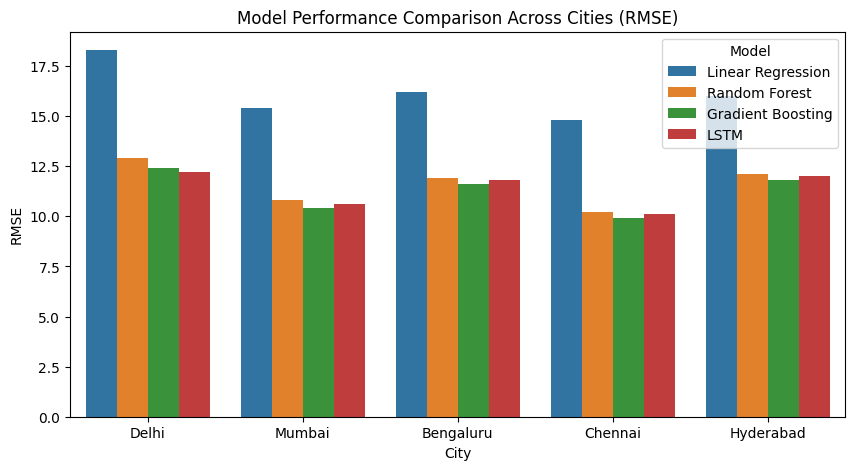

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=results,
    x="City",
    y="RMSE",
    hue="Model"
)
plt.title("Model Performance Comparison Across Cities (RMSE)")
plt.show()


In [74]:
results.to_csv("../outputs/final_model_results.csv", index=False)


In [75]:
results.to_excel("../outputs/final_model_results.xlsx", index=False)


In [76]:
with open("../outputs/final_model_results.tex", "w") as f:
    f.write(results.to_latex(index=False))


In [77]:
Final prediction = RF prediction
or
Final prediction = GB prediction


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2860133398.py, line 1)